In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 2.1 Collect the Data

In [18]:
df = pd.read_csv("noisy_curvefit_data.csv")

In [19]:
print(df.shape) # 100 rows, 6 columns!

(100, 6)


In [20]:
print(df.columns)

Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


In [21]:
print(df.head())
print(df.tail())

          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


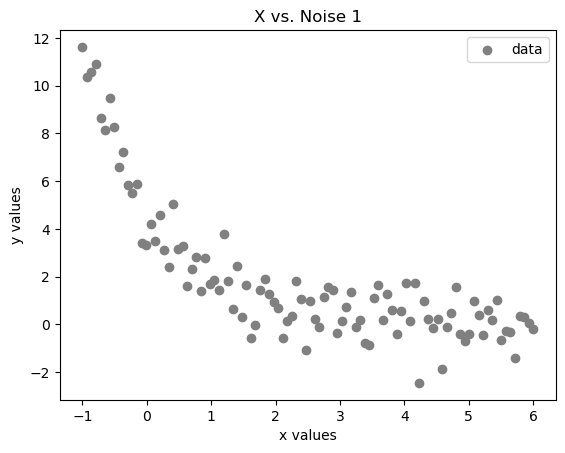

In [89]:
x = df['x']
y_1 = df['y_noise_1']
y_2 = df['y_noise_2']
y_3 = df['y_noise_3']
y_4 = df['y_noise_4']
y_5 = df['y_noise_5']

plt.figure()
plt.scatter(x, y_1, label = 'data', color = 'gray')
plt.xlabel("x values")
plt.ylabel("y values")
plt.title("X vs. Noise 1")
plt.legend()

plt.show()

# 2.2 Fit the Data

In [61]:
def model(x, A, k):
    return A * np.exp(- k * x)

In [62]:
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_1, p0 = p0)

A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [66]:
residuals = y_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(chi2_reduced)

0.7906732087457324


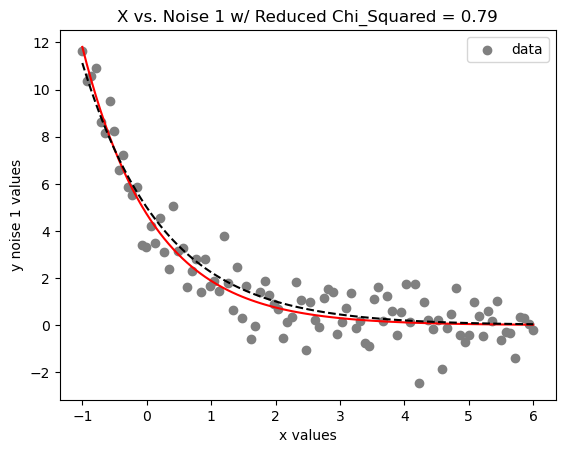

In [70]:
plt.figure()
plt.scatter(x, y_1, label = 'data', color = 'gray')
plt.plot(x, model(x, *popt), color = 'red')
plt.plot(x, model(x, 5, 0.8), linestyle = "--", color = 'black')
plt.xlabel("x values")
plt.ylabel("y noise 1 values")
plt.title("X vs. Noise 1 w/ Reduced Chi_Squared = 0.79")
plt.legend()

plt.show()

# 2.3 Compare Different Noise Levels

In [92]:
def model(x, A, k):
    return A * np.exp(- k * x)
    
def fit_model(x, y): 
    popt, pcov = curve_fit(model, x, y, p0 = p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return popt, chi2_reduced

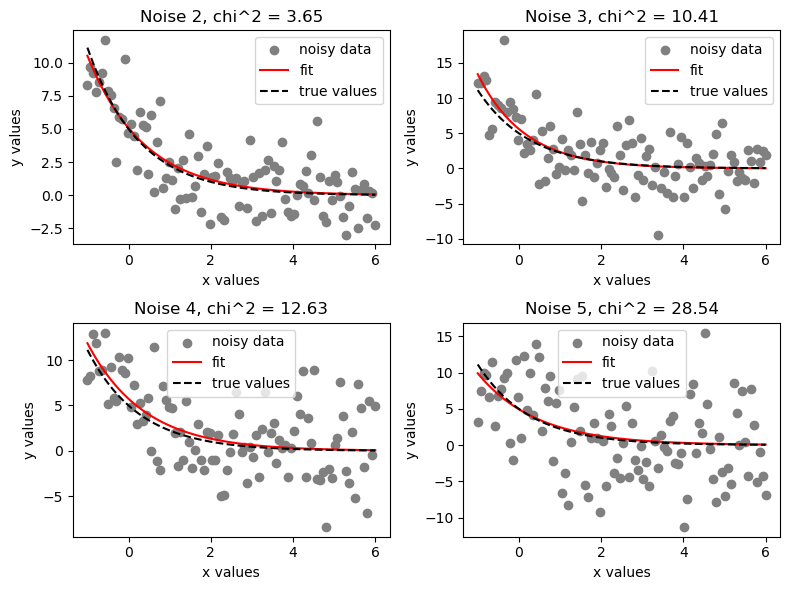

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

y_true = model(x, 5, 0.8)
datasets = [y_2, y_3, y_4, y_5]
noise_levels = [2, 3, 4, 5]

for i, (y_data, noise) in enumerate(zip(datasets, noise_levels)):
    ax = axes[i]
    popt, chi2_reduced = fit_model(x, y_data)
    y_fit = model(x, *popt)
    ax.scatter(x, y_data, color = "gray", label = "noisy data")
    ax.plot(x, y_fit, color = "red", label = "fit")
    ax.plot(x, y_true, linestyle = "--", color = "black", label = "true values")
    ax.set_title(f"Noise {noise}, chi^2 = {chi2_reduced:.2f}")
    ax.set_xlabel("x values")
    ax.set_ylabel("y values")
    ax.legend()
    
plt.tight_layout()
plt.show()

In [ ]:
# The red and black lines line up less and less as the amount of noise increases in the data sets.
# The reduced chi-squared value increases because noise level 2-5 has increasing amounts of noise, meaning the chi^2 value will get further away from 1.

# 2.4 Save Your Results

In [97]:
noise_list = []
A_list = []
k_list = []
chi2_list = []

for i, (y_data, noise) in enumerate(zip(datasets, noise_levels)):
    ax = axes[i]
    popt, chi2_reduced = fit_model(x, y_data)
    y_fit = model(x, *popt)
    ax.scatter(x, y_data, color = "gray", label = "noisy data")
    ax.plot(x, y_fit, color = "red", label = "fit")
    ax.plot(x, y_true, linestyle = "--", color = "black", label = "true values")
    ax.set_title(f"Noise {noise}, chi^2 = {chi2_reduced:.2f}")
    ax.set_xlabel("x values")
    ax.set_ylabel("y values")
    ax.legend()
    noise_list.append(noise)
    A_list.append(A_fit)
    k_list.append(k_fit)
    chi2_list.append(chi2_reduced)

df = pd.DataFrame({
    "Noise level": noise_list,
    "A fit": A_list,
    "k fit": k_list,
    "Reduced chi-squared": chi2_list
})

print(df)

   Noise level     A fit     k fit  Reduced chi-squared
0            2  4.714814  0.918308             3.649382
1            3  4.714814  0.918308            10.410207
2            4  4.714814  0.918308            12.626832
3            5  4.714814  0.918308            28.538124


In [98]:
df.to_csv("noise_parameters.csv", index = False)